In [2]:
class node():
    def __init__(self, xpos, ypos):

        self.xpos = xpos
        self.ypos = ypos

    def __repr__(self):
        return f"node(xpos={self.xpos}, ypos={self.ypos})"

   

In [3]:
import random
class mapper():
    def __init__(self):

        repete = int(input("Number of population nodes: "))
        grid = int(input("Grid size"))

        self.node_dic = {}

        i = 0
        while i < repete: 

            

            xx = random.uniform(0, grid)
            yy = random.uniform(0, grid)


            new = node(xx,yy)

            self.node_dic.update({new: {'connections': [], 'attributes': []}})

            i += 1


            
        

In [13]:
class connector():
    def __init__(self, node_dic):

        self.nodes = node_dic

        length_list = []

        for noodle in self.nodes:
            temp_list = []
            for noodle2 in self.nodes:
                dist = ((noodle.xpos-noodle2.xpos)**2 + (noodle.ypos - noodle2.ypos)**2)**.5
                temp_list.append(dist)

            minn = min(temp_list)
            length_list.append(minn)

        length_s = len(length_list)
        summ = 0
    
        for numb in length_list:

            summ += numb

        av = summ/length_s
            
                
            

        for node1 in self.nodes:
            for node2 in self.nodes:
                if ((((int(node1.xpos) - int(node2.xpos))**2) + ((int(node1.ypos) - int(node2.ypos))**2))**0.5 <= av) and (node1.xpos != node2.xpos and node1.ypos != node2.ypos):
                    self.nodes[node1]['connections'].append(node2)
                    
                    
                    

        

Number of population nodes:  10
Grid size 5


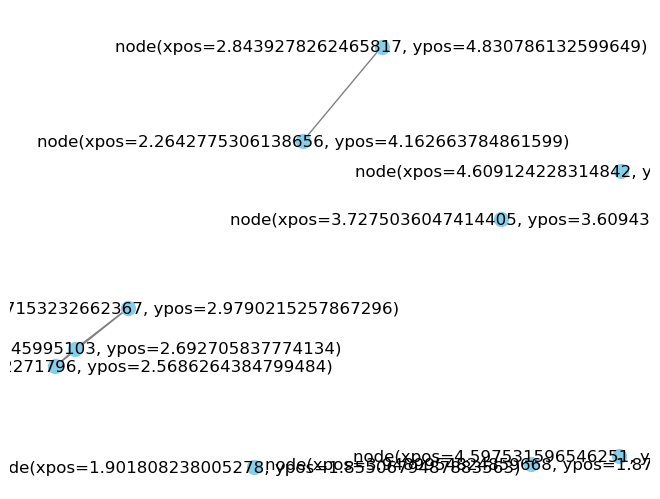

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

my_mapper = mapper()
my_connector = connector(my_mapper.node_dic)
#print(my_mapper.node_dic)

g = nx.Graph()
pos = {}

for start in my_mapper.node_dic:
    g.add_node(start)
    pos.update({start: (start.xpos, start.ypos)})
    for connect in my_mapper.node_dic[start]['connections']:
        g.add_edge(start, connect)

nx.draw(g, pos, with_labels=True, node_color='skyblue', node_size=100, edge_color='gray')
plt.show()
